# SIM 1000s vs SIM 3000s — model comparison

Both families use the same `A1000` mesh, the same 10-level internal-pressure sweep
(`P = [0.0] + [0.04 * sqrt(2)^i for i in 0..8]`, i.e. `P = 0, 0.04, ..., 0.64`),
the same -5 mm compression ramp, and the same modulus `E = 20`. They differ in both
the constitutive model and the Abaqus Step-1 solution scheme:

- **1000s** (sims 1000-1009): linear elastic material; `*Static, stabilize, factor=2e-5`
- **3000s** (sims 3000-3009): neo-Hookean material; `*Dynamic, application=QUASI-STATIC,
  initial=NO` with mass scaling (`*Density = 1e-6`)

Pressure levels are index-aligned: `1000+i` and `3000+i` share the same gas pressure `P`
for `i = 0..9`. Every plot overlays both families at matched pressure: **color** encodes
the pressure level (shared colormap/colorbar), while **line style** encodes the family
(`solid = static linear / 1000s`, `dashed = dynamic neo-Hookean / 3000s`).

This notebook follows `SIM_1010s_3010s_comparison.ipynb`. It reads reduced simulation
files through `I001_Results/AAA_fwd` when needed. Cache-dependent sections look for
`*_1000s.pkl` and `*_3000s.pkl` in this notebook folder and report missing caches rather
than recomputing expensive reductions. Generate those caches before using the affected
plots. Outputs are intentionally cleared so old 1010s/3010s figures are never shown as
results for these families.


In [1]:
import sys, os, pickle, json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

sys.path.insert(0, os.path.abspath('..'))

RESULTS_DIR = '../I001_Results'
OBJ_DIR     = '../I001_Results/OBJ_files'

SIMS_STATIC  = list(range(1000, 1010))   # 1000s
SIMS_DYNAMIC = list(range(3000, 3010))   # 3000s

FAMILIES = [
    dict(key='1000s', label='Static linear (1000s)',  sims=SIMS_STATIC,  ls='-',  marker='o', zorder=3),
    dict(key='3000s', label='Dynamic neo-Hookean (3000s)',  sims=SIMS_DYNAMIC, ls='--', marker='s', zorder=4),
]
ALL_SIMS = SIMS_STATIC + SIMS_DYNAMIC
N_LEVELS = 10   # pressure levels per family, index = sim % 10
E_MOD = 20.0


In [2]:
def load_pkl(path):
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    fwd_file = os.path.join(RESULTS_DIR, 'AAA_fwd')
    if os.path.exists(fwd_file):
        with open(fwd_file) as f:
            fwd_dir = f.read().strip()
        fwd_path = os.path.join(fwd_dir, os.path.relpath(path, RESULTS_DIR))
        if os.path.exists(fwd_path):
            with open(fwd_path, 'rb') as f:
                return pickle.load(f)
    return None

def resolve_path(path):
    if os.path.exists(path):
        return path
    fwd_file = os.path.join(RESULTS_DIR, 'AAA_fwd')
    if os.path.exists(fwd_file):
        with open(fwd_file) as f:
            fwd_dir = f.read().strip()
        fwd_path = os.path.join(fwd_dir, os.path.relpath(path, RESULTS_DIR))
        if os.path.exists(fwd_path):
            return fwd_path
    return None

def get_pressure(sim):
    path = resolve_path(os.path.join(OBJ_DIR, f'SIM_{sim:03d}.json'))
    if path is None:
        return None
    with open(path) as f:
        d = json.load(f)
    for step in d.get('steps', []):
        pb = step.get('Pressure_BC', 0)
        if pb:
            return float(pb)
    return 0.0

def get_E(sim):
    path = resolve_path(os.path.join(OBJ_DIR, f'SIM_{sim:03d}.json'))
    if path is None:
        return None
    with open(path) as f:
        d = json.load(f)
    return float(d['E'])

def displ_of(sim):
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        return None
    d = -np.array(a2['U2']['PERN-9999997'])
    del a2
    return d


In [3]:
PRESSURES = {sim: get_pressure(sim) for sim in ALL_SIMS}
print({sim: (f'{p:.6f} MPa' if p is not None else None) for sim, p in PRESSURES.items()})

# sanity check: pressure levels really are index-aligned between the two families
mismatch = [i for i in range(N_LEVELS)
            if PRESSURES.get(1000+i) is not None and PRESSURES.get(3000+i) is not None
            and abs(PRESSURES[1000+i] - PRESSURES[3000+i]) > 1e-9]
print('mismatched pressure levels:', mismatch)

# Report the light reduced files that drive the non-cache plots.
LIGHT_TYPES = ('A2', 'TP2_L', 'DEFC2', 'I3_BFS_3002')
AVAILABLE = {kind: {sim for sim in ALL_SIMS
                    if resolve_path(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_{kind}.pkl'))}
             for kind in LIGHT_TYPES}
for fam in FAMILIES:
    counts = ', '.join(f'{kind}={sum(sim in AVAILABLE[kind] for sim in fam["sims"])}/{N_LEVELS}'
                       for kind in LIGHT_TYPES)
    print(f"{fam['label']}: {counts}")
print('Plots can only compare families where both required result types are available.')


{1000: '0.000000 MPa', 1001: '0.040000 MPa', 1002: '0.056569 MPa', 1003: '0.080000 MPa', 1004: '0.113137 MPa', 1005: '0.160000 MPa', 1006: '0.226274 MPa', 1007: '0.320000 MPa', 1008: '0.452548 MPa', 1009: '0.640000 MPa', 3000: '0.000000 MPa', 3001: '0.040000 MPa', 3002: '0.056569 MPa', 3003: '0.080000 MPa', 3004: '0.113137 MPa', 3005: '0.160000 MPa', 3006: '0.226274 MPa', 3007: '0.320000 MPa', 3008: '0.452548 MPa', 3009: '0.640000 MPa'}
mismatched pressure levels: []
Static linear (1000s): A2=9/10, TP2_L=9/10, DEFC2=9/10, I3_BFS_3002=9/10
Dynamic neo-Hookean (3000s): A2=4/10, TP2_L=2/10, DEFC2=2/10, I3_BFS_3002=4/10
Plots can only compare families where both required result types are available.


In [4]:
PLASMA = plt.get_cmap('plasma', N_LEVELS)

def level_of(sim):
    return sim % 10

def color_of(sim):
    return PLASMA(level_of(sim))

def add_colorbar(fig, ax):
    sm = ScalarMappable(cmap=PLASMA, norm=Normalize(vmin=-0.5, vmax=N_LEVELS - 0.5))
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, ticks=range(N_LEVELS))
    labels = [f"{PRESSURES.get(1000+i, PRESSURES.get(3000+i)):.3g}" for i in range(N_LEVELS)]
    cb.ax.set_yticklabels(labels)
    cb.set_label('Gas pressure P (MPa)')
    return cb

def family_legend_handles():
    return [Line2D([], [], color='k', linestyle=fam['ls'], linewidth=1.8, label=fam['label'])
            for fam in FAMILIES]

def mark_unavailable(ax, message):
    """Annotate an axis instead of leaving a misleading blank plot."""
    ax.text(0.5, 0.5, message, transform=ax.transAxes, ha='center', va='center',
            fontsize=11, color='tab:red', wrap=True,
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='tab:red', alpha=0.9))


## Localization point

Same convention as the single-family notebooks: Localization A is the displacement at
the minimum of `shear_mean`, per sim. Computed independently for every sim in both
families whenever both `A2.pkl` and `TP2_L.pkl` are available. Missing simulations
are listed by the setup/readiness cell above and skipped safely.

In [5]:
LOC_A = {}
for sim in ALL_SIMS:
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ      = -np.array(a2['U2']['PERN-9999997'])
    shear_mean = np.array(tp2l['shear_mean'])
    del a2, tp2l
    LOC_A[sim] = displ[np.argmin(shear_mean)]
LOC_A


{1001: 2.680790424346924,
 1002: 2.7649545669555664,
 1003: 2.869436025619507,
 1004: 2.9933853149414062,
 1005: 3.1901838779449463,
 1006: 3.465122938156128,
 1007: 3.8300859928131104,
 1008: 4.43605899810791,
 1009: 4.965217113494873,
 3001: 2.833836078643799,
 3002: 2.9193477630615234}

## Shear mean / std and J / distortion caches (merged)

Loads the pre-built `shear_std_cache_*.pkl` and `J_distortion_cache_*.pkl` for both
families when present and merges them into one dict keyed by sim number (no collisions:
1000-1009 vs 3000-3009).

In [6]:
SHEAR_CACHE = {}
for fam in FAMILIES:
    path = f"shear_std_cache_{fam['key']}.pkl"
    if os.path.exists(path):
        with open(path, 'rb') as f:
            SHEAR_CACHE.update(pickle.load(f))
    else:
        print(f'missing {path}; using TP2_L fallback for shear_mean only')

# shear_mean already exists in the light TP2_L files. This fallback keeps Plots 1 and 3
# useful without loading the multi-gigabyte full TP2 files. shear_std still needs its cache.
for sim in ALL_SIMS:
    if sim in SHEAR_CACHE:
        continue
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if tp2l is not None:
        SHEAR_CACHE[sim] = {'t': np.asarray(tp2l['t']),
                            'shear_mean': np.asarray(tp2l['shear_mean'])}
print('shear_mean sims:', sorted(SHEAR_CACHE))
print('shear_std sims:', sorted(sim for sim, d in SHEAR_CACHE.items() if 'shear_std' in d))


missing shear_std_cache_1000s.pkl; using TP2_L fallback for shear_mean only
shear_mean sims: [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 3001, 3002]
shear_std sims: []


In [7]:
J_DISTORTION_CACHE = {}
for fam in FAMILIES:
    path = f"J_distortion_cache_{fam['key']}.pkl"
    if os.path.exists(path):
        with open(path, 'rb') as f:
            J_DISTORTION_CACHE.update(pickle.load(f))
    else:
        print(f'missing {path}')
sorted(J_DISTORTION_CACHE.keys())


missing J_distortion_cache_1000s.pkl


[]

## Plot 1 — Shear mean (TP) vs compressive displacement from t=0


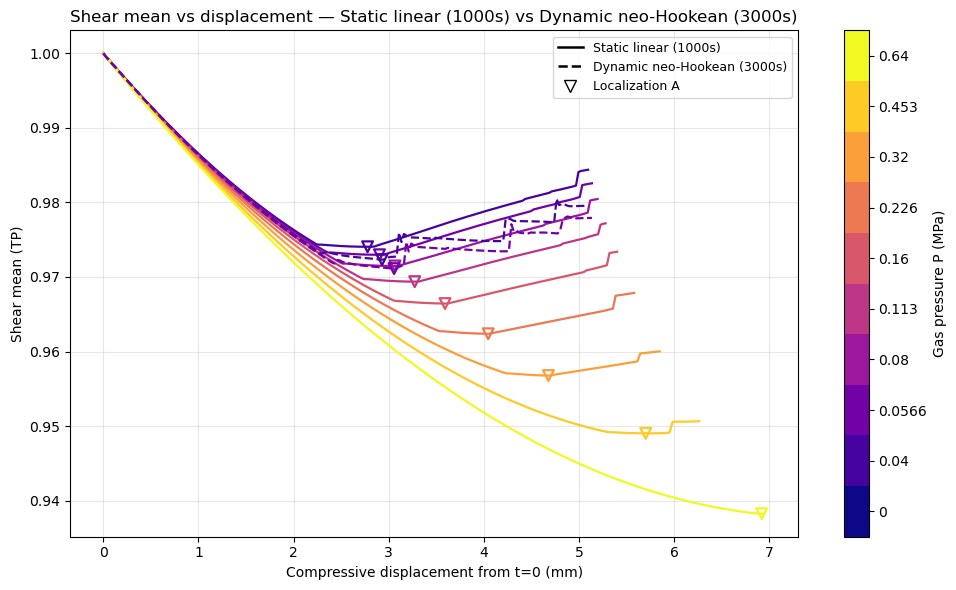

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

for fam in FAMILIES:
    for sim in fam['sims']:
        if sim not in SHEAR_CACHE:
            continue
        displ = displ_of(sim)
        if displ is None:
            continue
        y = SHEAR_CACHE[sim]['shear_mean']

        displ0     = displ[0]
        displ_zero = displ - displ0
        ax.plot(displ_zero, y, color=color_of(sim), linestyle=fam['ls'],
                linewidth=1.6, zorder=fam['zorder'])
        if sim in LOC_A:
            xA = LOC_A[sim] - displ0
            yA = np.interp(xA, displ_zero, y)
            ax.scatter(xA, yA, marker='v', s=60, facecolor='none',
                       edgecolor=color_of(sim), linewidths=1.6, zorder=6)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('Shear mean (TP)')
ax.set_title('Shear mean vs displacement — Static linear (1000s) vs Dynamic neo-Hookean (3000s)')
handles = family_legend_handles() + [Line2D([], [], marker='v', linestyle='None',
             markerfacecolor='none', markeredgecolor='k', markersize=8, label='Localization A')]
ax.legend(handles=handles, loc='best', fontsize=9)
add_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 2 — Standard deviation of shear (TP) vs compressive displacement from t=0


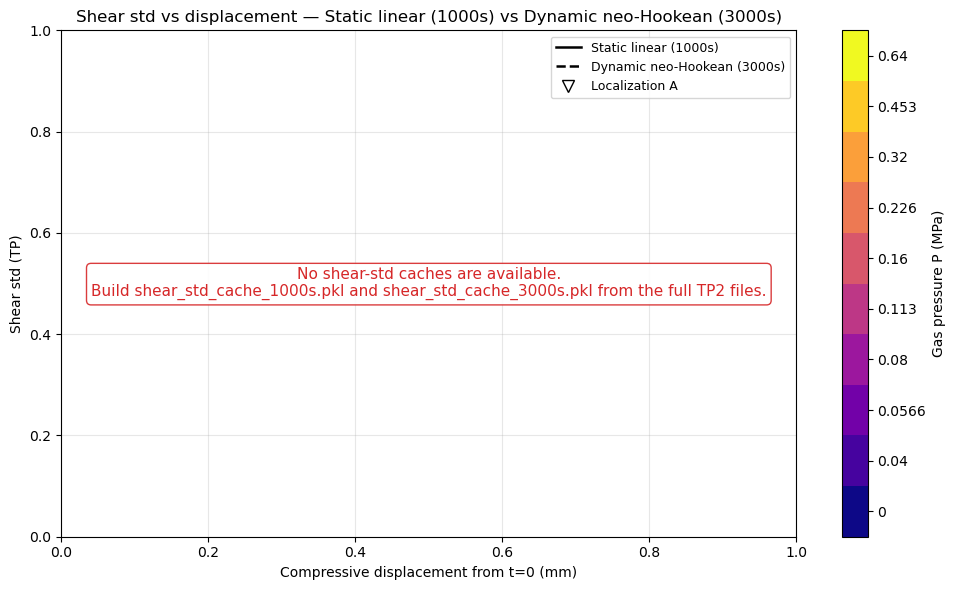

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

for fam in FAMILIES:
    for sim in fam['sims']:
        if sim not in SHEAR_CACHE or 'shear_std' not in SHEAR_CACHE[sim]:
            continue
        displ = displ_of(sim)
        if displ is None:
            continue
        y = SHEAR_CACHE[sim]['shear_std']

        displ0     = displ[0]
        displ_zero = displ - displ0
        ax.plot(displ_zero, y, color=color_of(sim), linestyle=fam['ls'],
                linewidth=1.6, zorder=fam['zorder'])
        if sim in LOC_A:
            xA = LOC_A[sim] - displ0
            yA = np.interp(xA, displ_zero, y)
            ax.scatter(xA, yA, marker='v', s=60, facecolor='none',
                       edgecolor=color_of(sim), linewidths=1.6, zorder=6)

if not any('shear_std' in d for d in SHEAR_CACHE.values()):
    mark_unavailable(ax, 'No shear-std caches are available.\nBuild shear_std_cache_1000s.pkl and shear_std_cache_3000s.pkl from the full TP2 files.')
ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('Shear std (TP)')
ax.set_title('Shear std vs displacement — Static linear (1000s) vs Dynamic neo-Hookean (3000s)')
handles = family_legend_handles() + [Line2D([], [], marker='v', linestyle='None',
             markerfacecolor='none', markeredgecolor='k', markersize=8, label='Localization A')]
ax.legend(handles=handles, loc='best', fontsize=9)
add_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 3 — d(Shear mean)/d(displacement) vs compressive displacement from t=0


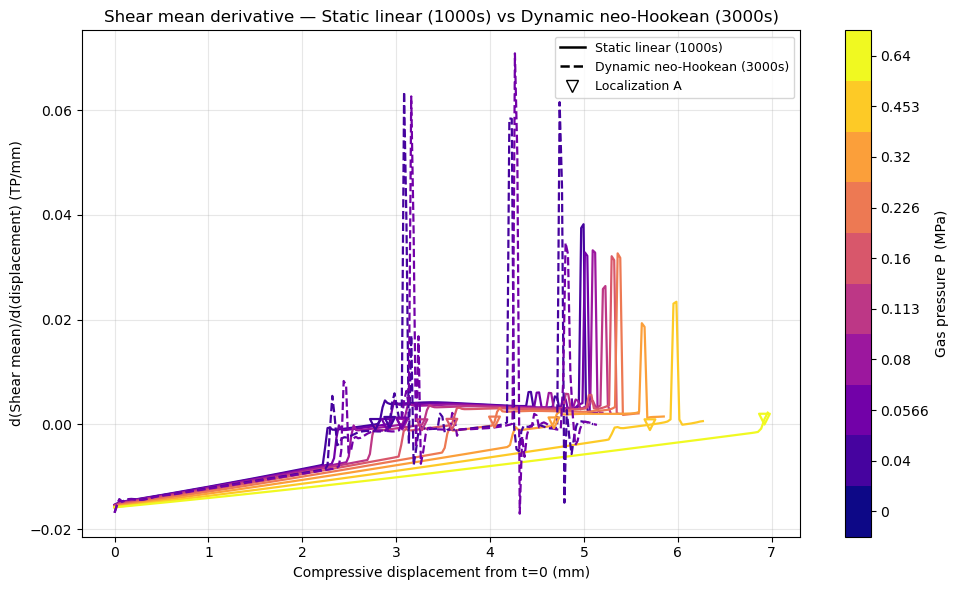

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

for fam in FAMILIES:
    for sim in fam['sims']:
        if sim not in SHEAR_CACHE:
            continue
        displ = displ_of(sim)
        if displ is None:
            continue
        y = SHEAR_CACHE[sim]['shear_mean']

        displ0     = displ[0]
        displ_zero = displ - displ0
        dy_dd = np.gradient(y, displ_zero)
        ax.plot(displ_zero, dy_dd, color=color_of(sim), linestyle=fam['ls'],
                linewidth=1.6, zorder=fam['zorder'])
        if sim in LOC_A:
            xA = LOC_A[sim] - displ0
            yA = np.interp(xA, displ_zero, dy_dd)
            ax.scatter(xA, yA, marker='v', s=60, facecolor='none',
                       edgecolor=color_of(sim), linewidths=1.6, zorder=6)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('d(Shear mean)/d(displacement) (TP/mm)')
ax.set_title('Shear mean derivative — Static linear (1000s) vs Dynamic neo-Hookean (3000s)')
handles = family_legend_handles() + [Line2D([], [], marker='v', linestyle='None',
             markerfacecolor='none', markeredgecolor='k', markersize=8, label='Localization A')]
ax.legend(handles=handles, loc='best', fontsize=9)
add_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 4 — d(Shear std)/d(displacement) vs compressive displacement from t=0


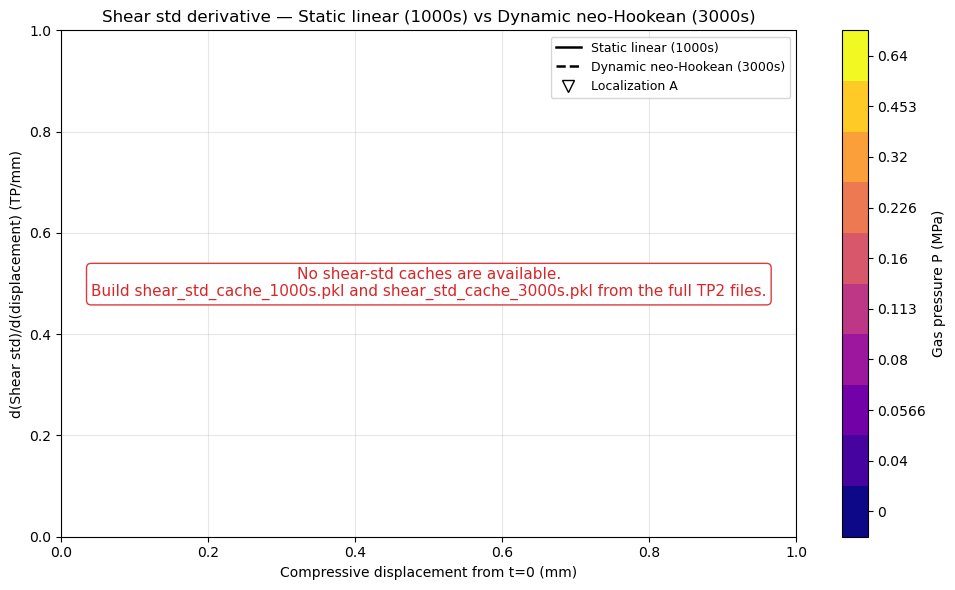

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

for fam in FAMILIES:
    for sim in fam['sims']:
        if sim not in SHEAR_CACHE or 'shear_std' not in SHEAR_CACHE[sim]:
            continue
        displ = displ_of(sim)
        if displ is None:
            continue
        y = SHEAR_CACHE[sim]['shear_std']

        displ0     = displ[0]
        displ_zero = displ - displ0
        dy_dd = np.gradient(y, displ_zero)
        ax.plot(displ_zero, dy_dd, color=color_of(sim), linestyle=fam['ls'],
                linewidth=1.6, zorder=fam['zorder'])
        if sim in LOC_A:
            xA = LOC_A[sim] - displ0
            yA = np.interp(xA, displ_zero, dy_dd)
            ax.scatter(xA, yA, marker='v', s=60, facecolor='none',
                       edgecolor=color_of(sim), linewidths=1.6, zorder=6)

if not any('shear_std' in d for d in SHEAR_CACHE.values()):
    mark_unavailable(ax, 'No shear-std caches are available.\nBuild shear_std_cache_1000s.pkl and shear_std_cache_3000s.pkl from the full TP2 files.')
ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('d(Shear std)/d(displacement) (TP/mm)')
ax.set_title('Shear std derivative — Static linear (1000s) vs Dynamic neo-Hookean (3000s)')
handles = family_legend_handles() + [Line2D([], [], marker='v', linestyle='None',
             markerfacecolor='none', markeredgecolor='k', markersize=8, label='Localization A')]
ax.legend(handles=handles, loc='best', fontsize=9)
add_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 5 — J mean (dilatational part of shear) vs compressive displacement from t=0


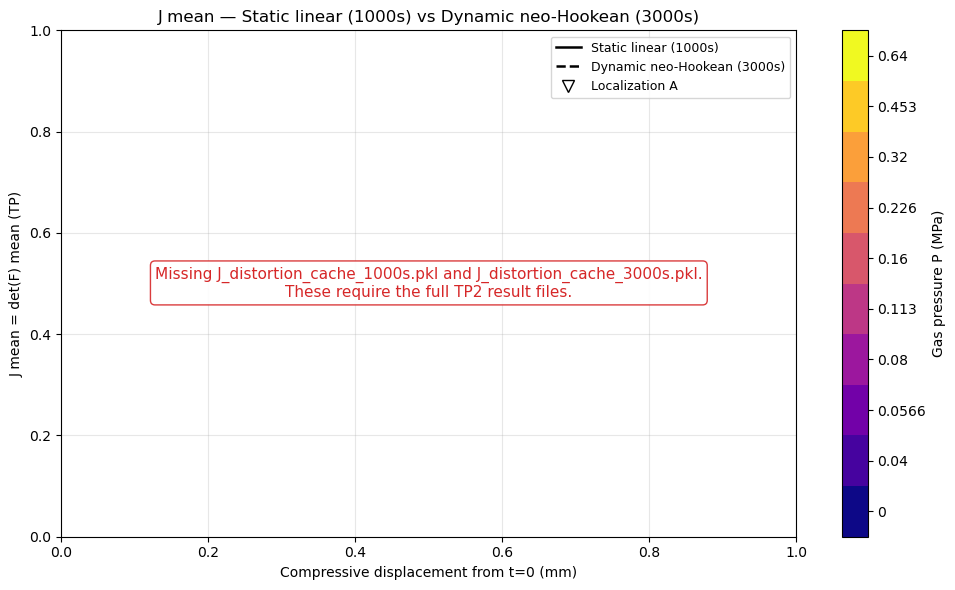

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

for fam in FAMILIES:
    for sim in fam['sims']:
        if sim not in J_DISTORTION_CACHE:
            continue
        displ = displ_of(sim)
        if displ is None:
            continue
        y = J_DISTORTION_CACHE[sim]['J_mean']

        displ0     = displ[0]
        displ_zero = displ - displ0
        ax.plot(displ_zero, y, color=color_of(sim), linestyle=fam['ls'],
                linewidth=1.6, zorder=fam['zorder'])
        if sim in LOC_A:
            xA = LOC_A[sim] - displ0
            yA = np.interp(xA, displ_zero, y)
            ax.scatter(xA, yA, marker='v', s=60, facecolor='none',
                       edgecolor=color_of(sim), linewidths=1.6, zorder=6)

if not J_DISTORTION_CACHE:
    mark_unavailable(ax, 'Missing J_distortion_cache_1000s.pkl and J_distortion_cache_3000s.pkl.\nThese require the full TP2 result files.')
ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('J mean = det(F) mean (TP)')
ax.set_title('J mean — Static linear (1000s) vs Dynamic neo-Hookean (3000s)')
handles = family_legend_handles() + [Line2D([], [], marker='v', linestyle='None',
             markerfacecolor='none', markeredgecolor='k', markersize=8, label='Localization A')]
ax.legend(handles=handles, loc='best', fontsize=9)
add_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 6 — Distortion mean (distortional part of shear) vs compressive displacement from t=0


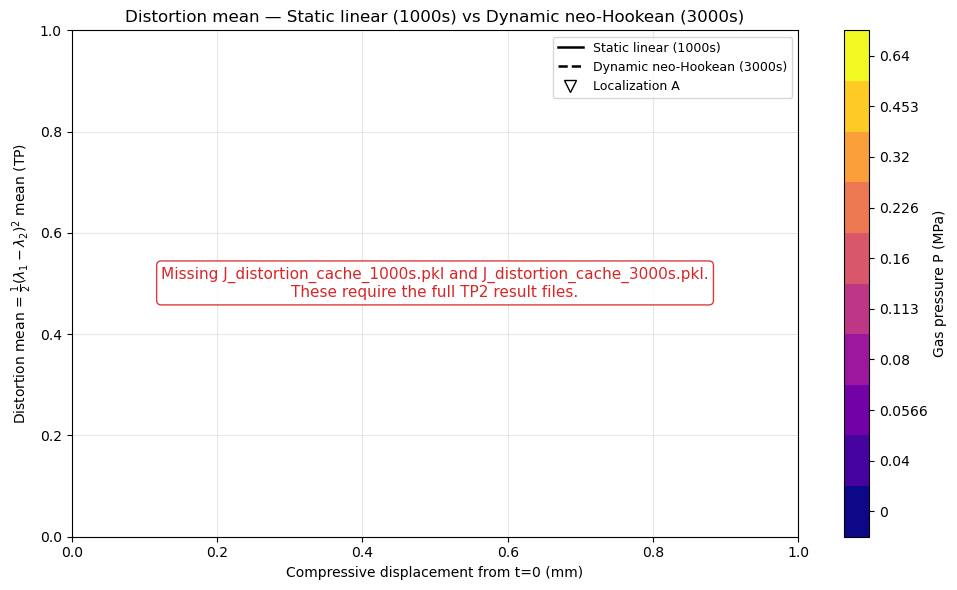

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

for fam in FAMILIES:
    for sim in fam['sims']:
        if sim not in J_DISTORTION_CACHE:
            continue
        displ = displ_of(sim)
        if displ is None:
            continue
        y = J_DISTORTION_CACHE[sim]['distortion_mean']

        displ0     = displ[0]
        displ_zero = displ - displ0
        ax.plot(displ_zero, y, color=color_of(sim), linestyle=fam['ls'],
                linewidth=1.6, zorder=fam['zorder'])
        if sim in LOC_A:
            xA = LOC_A[sim] - displ0
            yA = np.interp(xA, displ_zero, y)
            ax.scatter(xA, yA, marker='v', s=60, facecolor='none',
                       edgecolor=color_of(sim), linewidths=1.6, zorder=6)

if not J_DISTORTION_CACHE:
    mark_unavailable(ax, 'Missing J_distortion_cache_1000s.pkl and J_distortion_cache_3000s.pkl.\nThese require the full TP2 result files.')
ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('Distortion mean = $\\frac{1}{2}(\\lambda_1-\\lambda_2)^2$ mean (TP)')
ax.set_title('Distortion mean — Static linear (1000s) vs Dynamic neo-Hookean (3000s)')
handles = family_legend_handles() + [Line2D([], [], marker='v', linestyle='None',
             markerfacecolor='none', markeredgecolor='k', markersize=8, label='Localization A')]
ax.legend(handles=handles, loc='best', fontsize=9)
add_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 7 — eta_shear (area-weighted shear homogeneity index) vs compressive displacement from t=0


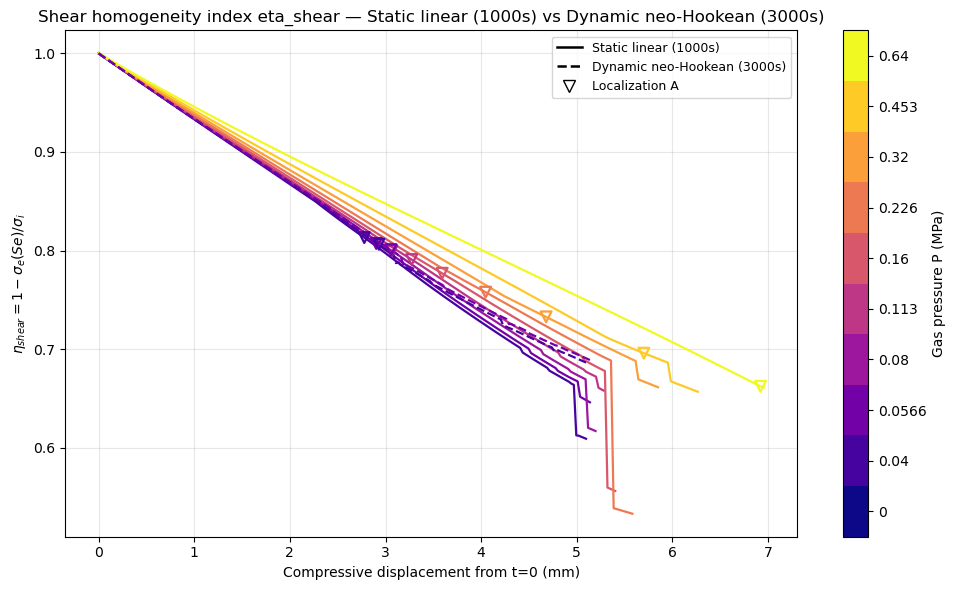

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

for fam in FAMILIES:
    for sim in fam['sims']:
        a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
        tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
        if a2 is None or tp2l is None:
            del a2, tp2l
            continue
        displ = -np.array(a2['U2']['PERN-9999997'])
        y     = np.array(tp2l['eta_shear'])
        del a2, tp2l

        displ0     = displ[0]
        displ_zero = displ - displ0
        ax.plot(displ_zero, y, color=color_of(sim), linestyle=fam['ls'],
                linewidth=1.6, zorder=fam['zorder'])
        if sim in LOC_A:
            xA = LOC_A[sim] - displ0
            yA = np.interp(xA, displ_zero, y)
            ax.scatter(xA, yA, marker='v', s=60, facecolor='none',
                       edgecolor=color_of(sim), linewidths=1.6, zorder=6)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('$\\eta_{shear} = 1 - \\sigma_e(Se)/\\sigma_i$')
ax.set_title('Shear homogeneity index eta_shear — Static linear (1000s) vs Dynamic neo-Hookean (3000s)')
handles = family_legend_handles() + [Line2D([], [], marker='v', linestyle='None',
             markerfacecolor='none', markeredgecolor='k', markersize=8, label='Localization A')]
ax.legend(handles=handles, loc='best', fontsize=9)
add_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 8 — eta (element-area homogeneity index) vs compressive displacement from t=0


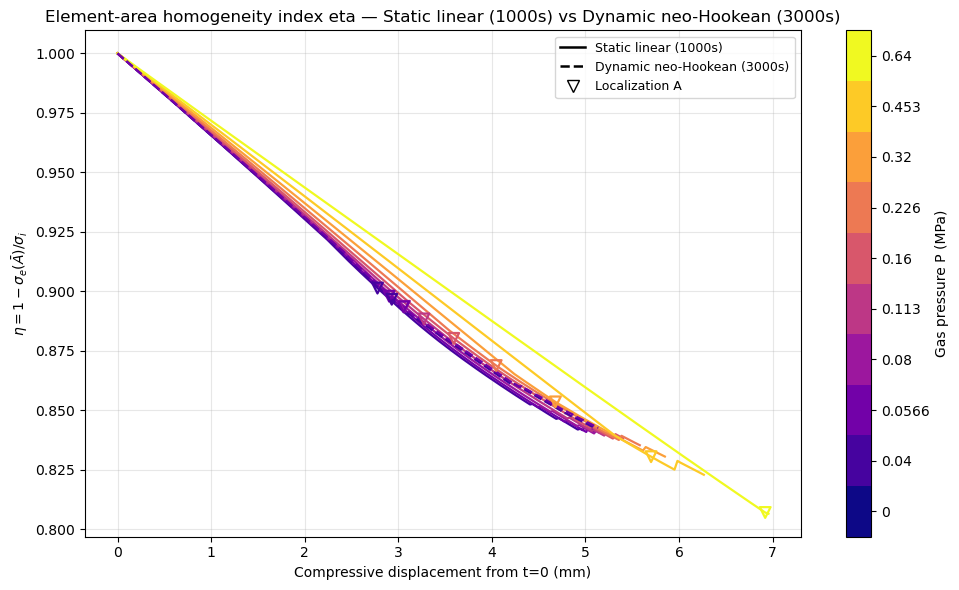

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

for fam in FAMILIES:
    for sim in fam['sims']:
        a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
        tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
        if a2 is None or tp2l is None:
            del a2, tp2l
            continue
        displ = -np.array(a2['U2']['PERN-9999997'])
        y     = np.array(tp2l['eta'])
        del a2, tp2l

        displ0     = displ[0]
        displ_zero = displ - displ0
        ax.plot(displ_zero, y, color=color_of(sim), linestyle=fam['ls'],
                linewidth=1.6, zorder=fam['zorder'])
        if sim in LOC_A:
            xA = LOC_A[sim] - displ0
            yA = np.interp(xA, displ_zero, y)
            ax.scatter(xA, yA, marker='v', s=60, facecolor='none',
                       edgecolor=color_of(sim), linewidths=1.6, zorder=6)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('$\\eta = 1 - \\sigma_e(\\bar{A})/\\sigma_i$')
ax.set_title('Element-area homogeneity index eta — Static linear (1000s) vs Dynamic neo-Hookean (3000s)')
handles = family_legend_handles() + [Line2D([], [], marker='v', linestyle='None',
             markerfacecolor='none', markeredgecolor='k', markersize=8, label='Localization A')]
ax.legend(handles=handles, loc='best', fontsize=9)
add_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 9 — etaC_A, etaC_R (hole-based localization indices) vs compressive displacement from t=0


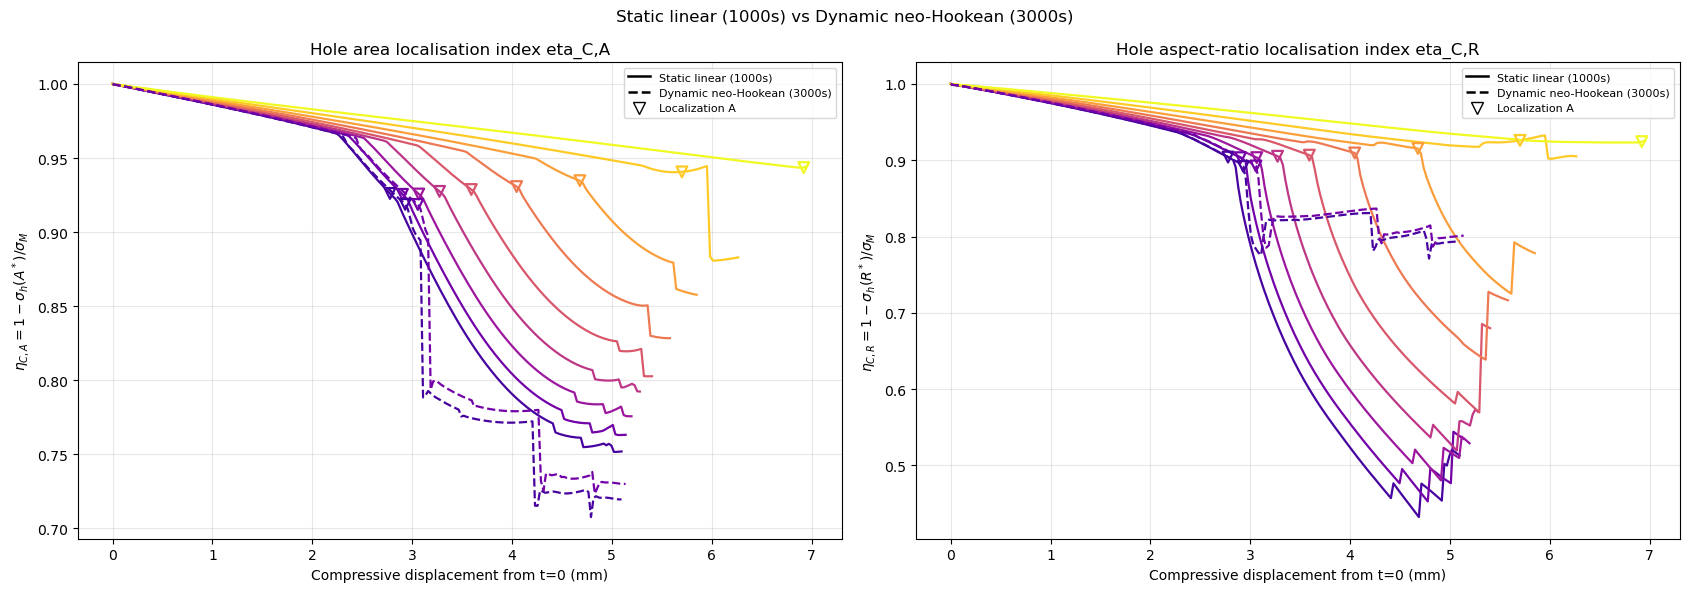

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))

for fam in FAMILIES:
    for sim in fam['sims']:
        defc2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_DEFC2.pkl'))
        if defc2 is None:
            continue
        displ  = -np.array(defc2['displacement'])
        etaC_A = np.array(defc2['etaC_A'])
        etaC_R = np.array(defc2['etaC_R'])
        del defc2

        displ0     = displ[0]
        displ_zero = displ - displ0

        ax1.plot(displ_zero, etaC_A, color=color_of(sim), linestyle=fam['ls'], linewidth=1.6, zorder=fam['zorder'])
        ax2.plot(displ_zero, etaC_R, color=color_of(sim), linestyle=fam['ls'], linewidth=1.6, zorder=fam['zorder'])
        if sim in LOC_A:
            xA = LOC_A[sim] - displ0
            yA1 = np.interp(xA, displ_zero, etaC_A)
            yA2 = np.interp(xA, displ_zero, etaC_R)
            ax1.scatter(xA, yA1, marker='v', s=60, facecolor='none', edgecolor=color_of(sim), linewidths=1.6, zorder=6)
            ax2.scatter(xA, yA2, marker='v', s=60, facecolor='none', edgecolor=color_of(sim), linewidths=1.6, zorder=6)

handles = family_legend_handles() + [Line2D([], [], marker='v', linestyle='None',
             markerfacecolor='none', markeredgecolor='k', markersize=8, label='Localization A')]

ax1.set_xlabel('Compressive displacement from t=0 (mm)')
ax1.set_ylabel(r'$\eta_{C,A} = 1 - \sigma_h(A^*)/\sigma_M$')
ax1.set_title('Hole area localisation index eta_C,A')
ax1.legend(handles=handles, loc='best', fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Compressive displacement from t=0 (mm)')
ax2.set_ylabel(r'$\eta_{C,R} = 1 - \sigma_h(R^*)/\sigma_M$')
ax2.set_title('Hole aspect-ratio localisation index eta_C,R')
ax2.legend(handles=handles, loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

fig.suptitle('Static linear (1000s) vs Dynamic neo-Hookean (3000s)')
fig.tight_layout()
plt.show()


## Plot 10 — w_cv (strain-energy-density coefficient of variation) vs compressive displacement from t=0


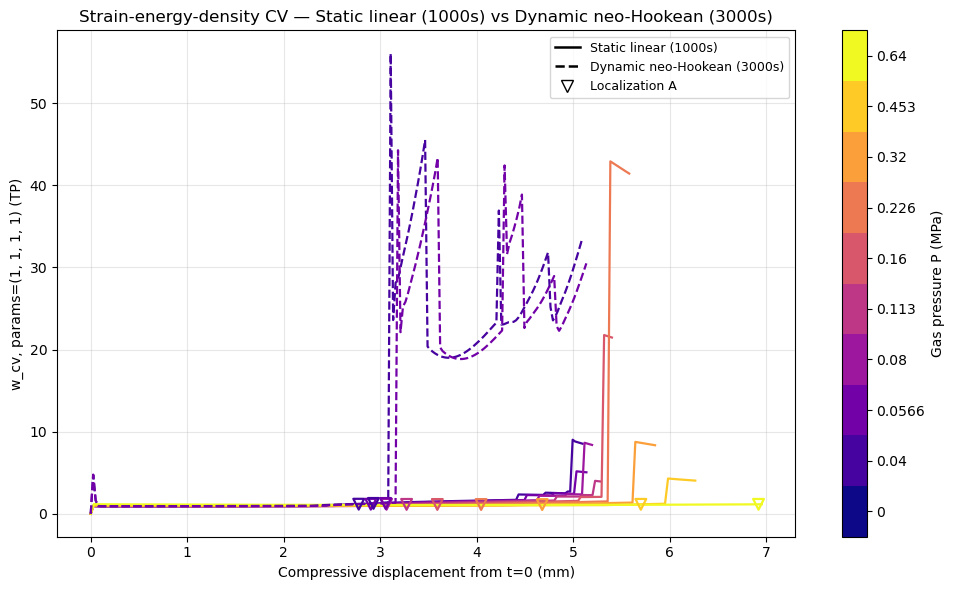

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
W_PARAMS = (1, 1, 1, 1)

for fam in FAMILIES:
    for sim in fam['sims']:
        a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
        tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
        if a2 is None or tp2l is None:
            del a2, tp2l
            continue
        displ = -np.array(a2['U2']['PERN-9999997'])
        w_cv  = np.array(tp2l['w_cv'][W_PARAMS])
        del a2, tp2l

        displ0     = displ[0]
        displ_zero = displ - displ0
        ax.plot(displ_zero, w_cv, color=color_of(sim), linestyle=fam['ls'], linewidth=1.6, zorder=fam['zorder'])
        if sim in LOC_A:
            xA = LOC_A[sim] - displ0
            yA = np.interp(xA, displ_zero, w_cv)
            ax.scatter(xA, yA, marker='v', s=60, facecolor='none', edgecolor=color_of(sim), linewidths=1.6, zorder=6)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel(f'w_cv, params={W_PARAMS} (TP)')
ax.set_title('Strain-energy-density CV — Static linear (1000s) vs Dynamic neo-Hookean (3000s)')
handles = family_legend_handles() + [Line2D([], [], marker='v', linestyle='None',
             markerfacecolor='none', markeredgecolor='k', markersize=8, label='Localization A')]
ax.legend(handles=handles, loc='best', fontsize=9)
add_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 11 — f (tension/compression network efficiency ratio) vs compressive strain from t=0

`f(t) = global_ef_t(t) / global_ef_c(t)` from `DATA_PICK_{sim}_I3_BFS_3002.pkl`. Plotted
on a log y-axis. Strain uses the zeroed convention `strain = (displ - displ[0]) / (20 - displ[0])`.
SIM 1000 and 3000 (`P = 0`) never cross `f = 1` and are excluded from the `f=1` story in
Plot 12 but are still plotted here.

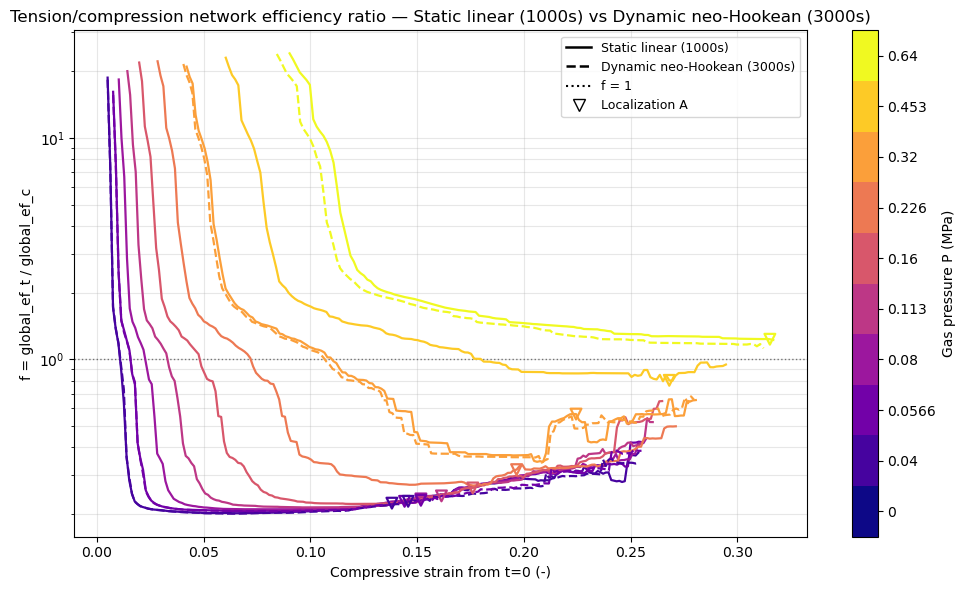

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

for fam in FAMILIES:
    for sim in fam['sims']:
        a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
        i3 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
        if a2 is None or i3 is None:
            del a2, i3
            continue
        displ = -np.array(a2['U2']['PERN-9999997'])
        ef_t  = np.array(i3['global_ef_t'], dtype=float)
        ef_c  = np.array(i3['global_ef_c'], dtype=float)
        del a2, i3

        with np.errstate(divide='ignore', invalid='ignore'):
            f_ratio = np.where(ef_c != 0, ef_t / ef_c, np.nan)
        del ef_t, ef_c

        displ0     = displ[0]
        displ_zero = displ - displ0
        height0    = 20 - displ0
        strain     = displ_zero / height0

        mask = ~np.isnan(f_ratio) & (displ > 0)
        ax.plot(strain[mask], f_ratio[mask], color=color_of(sim), linestyle=fam['ls'],
                linewidth=1.6, zorder=fam['zorder'])
        if sim in LOC_A:
            xA = (LOC_A[sim] - displ0) / height0
            yA = np.interp(xA, strain[mask], f_ratio[mask])
            ax.scatter(xA, yA, marker='v', s=60, facecolor='none', edgecolor=color_of(sim), linewidths=1.6, zorder=6)

ax.axhline(1.0, color='k', linestyle=':', linewidth=1, alpha=0.5)
ax.set_yscale('log')
ax.set_xlabel('Compressive strain from t=0 (-)')
ax.set_ylabel('f = global_ef_t / global_ef_c')
ax.set_title('Tension/compression network efficiency ratio — Static linear (1000s) vs Dynamic neo-Hookean (3000s)')
handles = family_legend_handles() + [Line2D([], [], color='k', linestyle=':', label='f = 1'),
             Line2D([], [], marker='v', linestyle='None', markerfacecolor='none',
                    markeredgecolor='k', markersize=8, label='Localization A')]
ax.legend(handles=handles, loc='best', fontsize=9)
add_colorbar(fig, ax)
ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
plt.show()


## Plot 12 — P/E vs strain at f = 1, both families overlaid

`eps(f=1)` found the same way as the single-family notebooks (first frame-to-frame
crossing of `f` through 1, linearly interpolated in strain). `P = 0` sims never cross
`f=1` and are excluded. Marker shape encodes family; color encodes pressure level.

In [19]:
loc_f1_data = []
for fam in FAMILIES:
    for sim in fam['sims']:
        a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
        i3 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
        E  = get_E(sim)
        if a2 is None or i3 is None or sim not in PRESSURES or E is None:
            del a2, i3
            continue
        displ = -np.array(a2['U2']['PERN-9999997'])
        ef_t  = np.array(i3['global_ef_t'], dtype=float)
        ef_c  = np.array(i3['global_ef_c'], dtype=float)
        del a2, i3

        with np.errstate(divide='ignore', invalid='ignore'):
            f_ratio = np.where(ef_c != 0, ef_t / ef_c, np.nan)
        del ef_t, ef_c

        mask = ~np.isnan(f_ratio) & (displ > 0)
        displ_m, f_m = displ[mask], f_ratio[mask]

        displ0  = displ[0]
        height0 = 20 - displ0
        strain_m = (displ_m - displ0) / height0

        eps_f1 = None
        for i in range(len(f_m) - 1):
            if f_m[i] >= 1 and f_m[i + 1] < 1:
                frac = (1 - f_m[i]) / (f_m[i + 1] - f_m[i])
                eps_f1 = strain_m[i] + frac * (strain_m[i + 1] - strain_m[i])
                break
        if eps_f1 is None:
            continue

        P = PRESSURES[sim]
        loc_f1_data.append(dict(sim=sim, fam=fam['key'], marker=fam['marker'], ls=fam['ls'],
                                 P=P, E=E, P_over_E=P / E, eps_f1=eps_f1))

loc_f1_data.sort(key=lambda d: (d['fam'], d['P_over_E']))
loc_f1_data


[{'sim': 1001,
  'fam': '1000s',
  'marker': 'o',
  'ls': '-',
  'P': 0.04,
  'E': 20.0,
  'P_over_E': 0.002,
  'eps_f1': 0.010944298670717844},
 {'sim': 1002,
  'fam': '1000s',
  'marker': 'o',
  'ls': '-',
  'P': 0.05656854249492381,
  'E': 20.0,
  'P_over_E': 0.0028284271247461905,
  'eps_f1': 0.0158279786604957},
 {'sim': 1003,
  'fam': '1000s',
  'marker': 'o',
  'ls': '-',
  'P': 0.08000000000000002,
  'E': 20.0,
  'P_over_E': 0.004000000000000001,
  'eps_f1': 0.02271912157289598},
 {'sim': 1004,
  'fam': '1000s',
  'marker': 'o',
  'ls': '-',
  'P': 0.11313708498984763,
  'E': 20.0,
  'P_over_E': 0.005656854249492382,
  'eps_f1': 0.03314005137834569},
 {'sim': 1005,
  'fam': '1000s',
  'marker': 'o',
  'ls': '-',
  'P': 0.16000000000000003,
  'E': 20.0,
  'P_over_E': 0.008000000000000002,
  'eps_f1': 0.04824771153047839},
 {'sim': 1006,
  'fam': '1000s',
  'marker': 'o',
  'ls': '-',
  'P': 0.2262741699796953,
  'E': 20.0,
  'P_over_E': 0.011313708498984765,
  'eps_f1': 0.072090

### Plot 12 (figure)


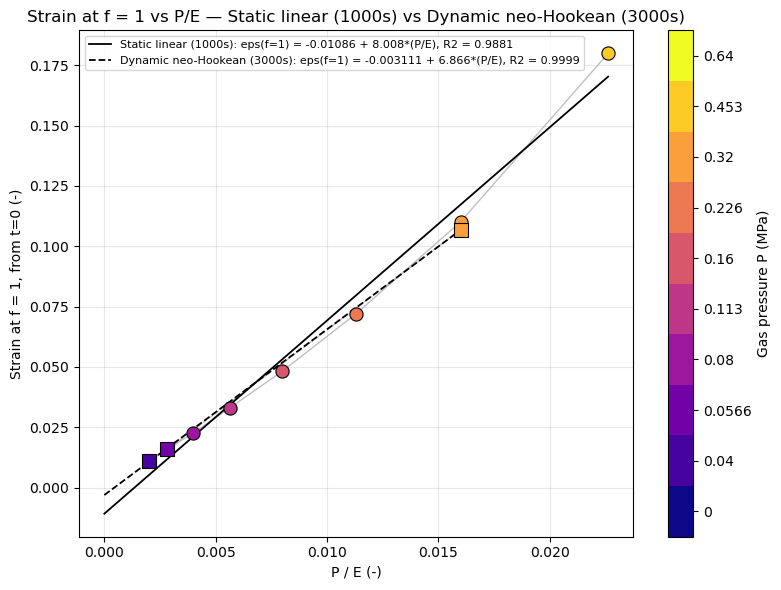

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

for d in loc_f1_data:
    ax.scatter(d['P_over_E'], d['eps_f1'], marker=d['marker'], s=90, color=color_of(d['sim']),
               edgecolor='k', linewidths=0.8, zorder=5)

for fam in FAMILIES:
    pts = [d for d in loc_f1_data if d['fam'] == fam['key']]
    if not pts:
        continue
    x = np.array([d['P_over_E'] for d in pts])
    y = np.array([d['eps_f1'] for d in pts])
    ax.plot(x, y, color='gray', linestyle=fam['ls'], linewidth=1, alpha=0.5, zorder=1)
    slope, intercept = np.polyfit(x, y, 1)
    r2 = 1 - np.sum((y - (slope * x + intercept))**2) / np.sum((y - y.mean())**2)
    xfit = np.linspace(0, x.max(), 50)
    ax.plot(xfit, slope * xfit + intercept, color='k', linestyle=fam['ls'], linewidth=1.3,
            label=f"{fam['label']}: eps(f=1) = {intercept:.4g} + {slope:.4g}*(P/E), R2 = {r2:.4f}")

ax.set_xlabel('P / E (-)')
ax.set_ylabel('Strain at f = 1, from t=0 (-)')
ax.set_title('Strain at f = 1 vs P/E — Static linear (1000s) vs Dynamic neo-Hookean (3000s)')
ax.legend(loc='best', fontsize=8)
add_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Skeleton-pressure caches (merged)

Loads `p_cache_1000s.pkl` / `p_cache_3000s.pkl` when present. Each cache contains
`p_e(t) = -(S11_e + S22_e)/2`, its population mean per frame, and 5 landmark snapshots.
The two dictionaries are merged the same way as the shear/J caches above.

In [21]:
PSKEL = {}
for fam in FAMILIES:
    path = f"p_cache_{fam['key']}.pkl"
    if os.path.exists(path):
        with open(path, 'rb') as f:
            PSKEL.update(pickle.load(f))
    else:
        print(f'missing {path}')
sorted(PSKEL.keys())


missing p_cache_1000s.pkl


[3001, 3002]

## Plot 13 — Mean skeleton pressure p vs strain


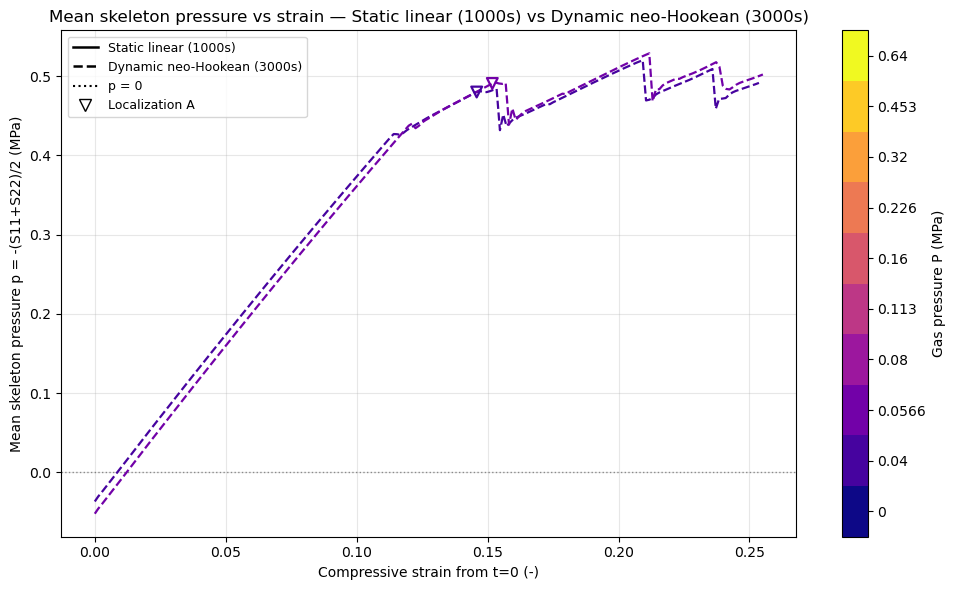

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

for fam in FAMILIES:
    for sim in fam['sims']:
        if sim not in PSKEL:
            continue
        displ = displ_of(sim)
        if displ is None:
            continue
        mean_p = PSKEL[sim]['mean_p']

        displ0  = displ[0]
        height0 = 20 - displ0
        strain  = (displ - displ0) / height0

        ax.plot(strain, mean_p, color=color_of(sim), linestyle=fam['ls'], linewidth=1.6, zorder=fam['zorder'])
        if sim in LOC_A:
            xA = (LOC_A[sim] - displ0) / height0
            yA = np.interp(xA, strain, mean_p)
            ax.scatter(xA, yA, marker='v', s=60, facecolor='none', edgecolor=color_of(sim), linewidths=1.6, zorder=6)

if not PSKEL:
    mark_unavailable(ax, 'Missing p_cache_1000s.pkl and p_cache_3000s.pkl.\nThese require reduced B stress files.')
ax.axhline(0.0, color='k', linestyle=':', linewidth=1, alpha=0.4)
ax.set_xlabel('Compressive strain from t=0 (-)')
ax.set_ylabel('Mean skeleton pressure p = -(S11+S22)/2 (MPa)')
ax.set_title('Mean skeleton pressure vs strain — Static linear (1000s) vs Dynamic neo-Hookean (3000s)')
handles = family_legend_handles() + [Line2D([], [], color='k', linestyle=':', label='p = 0'),
             Line2D([], [], marker='v', linestyle='None', markerfacecolor='none',
                    markeredgecolor='k', markersize=8, label='Localization A')]
ax.legend(handles=handles, loc='best', fontsize=9)
add_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 14 — p0 (gas pre-tension) and p* (at Localization A) vs internal gas pressure

Tests whether the compaction-limit skeleton pressure `p*` is model-independent.

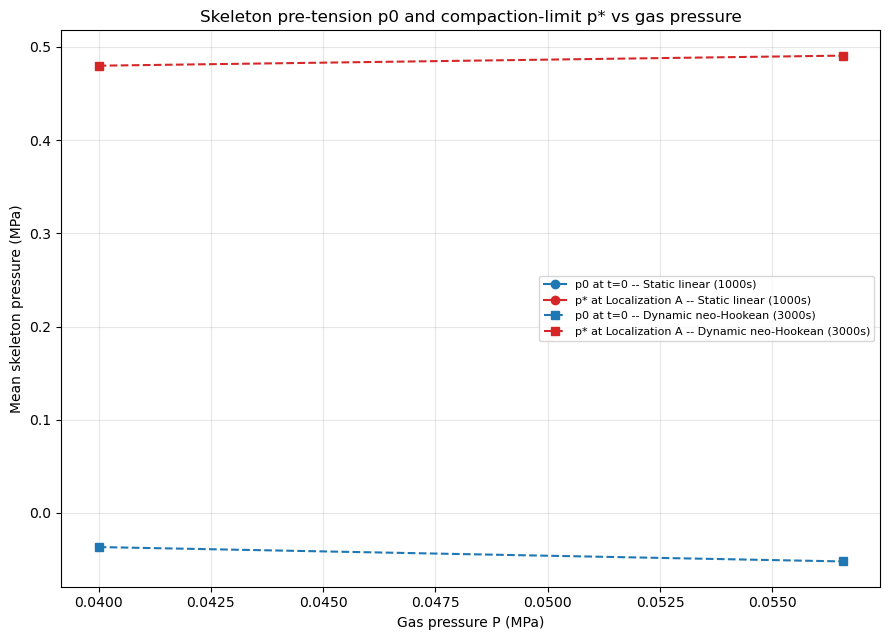

{'sim': 3001, 'fam': '3000s', 'marker': 's', 'ls': '--', 'P': 0.04, 'p0': -0.03661182068367679, 'p_star': 0.4798332485052862, 'pinned': False}
{'sim': 3002, 'fam': '3000s', 'marker': 's', 'ls': '--', 'P': 0.05656854249492381, 'p0': -0.052033988210335905, 'p_star': 0.4906473128905921, 'pinned': False}


In [23]:
rows = []
for fam in FAMILIES:
    for sim in fam['sims']:
        if sim not in PSKEL or sim not in PRESSURES:
            continue
        p = np.asarray(PSKEL[sim]['mean_p'], dtype=float)
        shear = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
        if shear is None:
            continue
        shear_mean = np.array(shear['shear_mean'])
        del shear
        i_star = int(np.argmin(shear_mean))
        pinned = (i_star == len(shear_mean) - 1)
        rows.append(dict(sim=sim, fam=fam['key'], marker=fam['marker'], ls=fam['ls'],
                          P=PRESSURES[sim], p0=p[0], p_star=p[i_star], pinned=pinned))

fig, ax = plt.subplots(figsize=(9, 6.5))
for fam in FAMILIES:
    r = [d for d in rows if d['fam'] == fam['key']]
    r.sort(key=lambda d: d['P'])
    Pg    = np.array([d['P'] for d in r])
    p0    = np.array([d['p0'] for d in r])
    pstar = np.array([d['p_star'] for d in r])
    ok    = ~np.array([d['pinned'] for d in r], dtype=bool)
    ax.plot(Pg, p0, marker=fam['marker'], linestyle=fam['ls'], color='tab:blue',
            label=f"p0 at t=0 -- {fam['label']}")
    ax.plot(Pg[ok], pstar[ok], marker=fam['marker'], linestyle=fam['ls'], color='tab:red',
            label=f"p* at Localization A -- {fam['label']}")

if not rows:
    mark_unavailable(ax, 'No skeleton-pressure rows are available.\nBuild the p_cache files after reducing the simulations.')
ax.set_xlabel('Gas pressure P (MPa)')
ax.set_ylabel('Mean skeleton pressure (MPa)')
ax.set_title('Skeleton pre-tension p0 and compaction-limit p* vs gas pressure')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

for r in sorted(rows, key=lambda d: (d['fam'], d['P'])):
    print(r)


## Percolation caches (merged, both families)

`bar_fraction_cache_*.pkl`, `cluster_diagnostics_*.pkl` (per-sim, merged as above) and
`random_percolation_null_*.pkl` (one dict per family — kept separate because the two
model families could land on slightly different overlay realisations, though both use
the same `A1000_I3002.gridhex.json` mesh).

In [24]:
BF, CL = {}, {}
NULL = {}
for fam in FAMILIES:
    bf_path = f"bar_fraction_cache_{fam['key']}.pkl"
    cl_path = f"cluster_diagnostics_{fam['key']}.pkl"
    nu_path = f"random_percolation_null_{fam['key']}.pkl"
    if os.path.exists(bf_path):
        with open(bf_path, 'rb') as f: BF.update(pickle.load(f))
    if os.path.exists(cl_path):
        with open(cl_path, 'rb') as f: CL.update(pickle.load(f))
    if os.path.exists(nu_path):
        with open(nu_path, 'rb') as f: NULL[fam['key']] = pickle.load(f)
print('BF sims:', sorted(BF.keys()))
print('CL sims:', sorted(CL.keys()))
print('NULL families:', list(NULL.keys()))


BF sims: []
CL sims: []
NULL families: ['3000s']


## Plot 15 — f vs tension-bar fraction q, both families + both null models

If `f` collapses onto one curve as a function of `q` alone, the model choice should not
matter for this relationship.

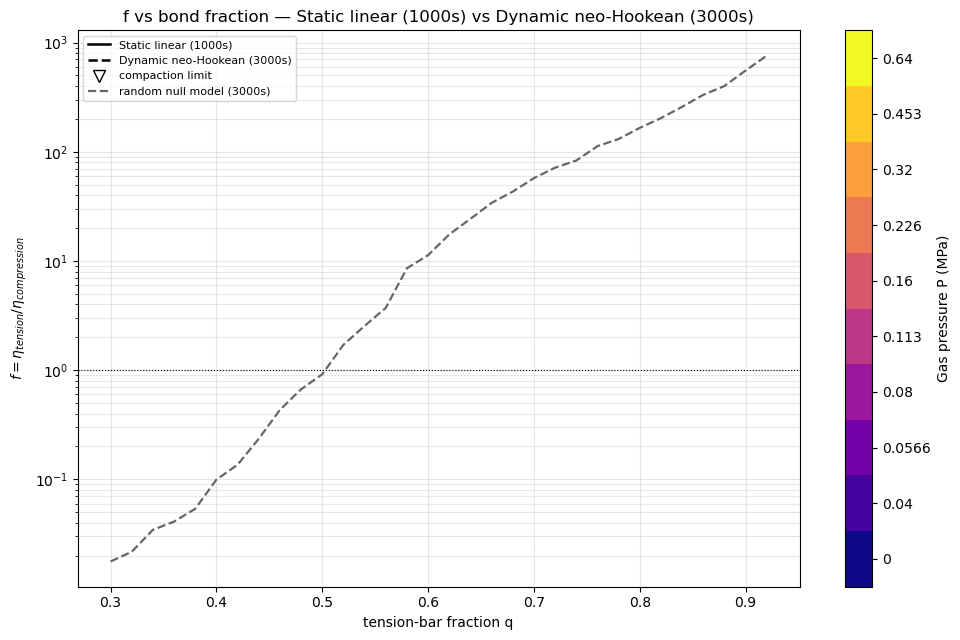

In [25]:
fig, ax = plt.subplots(figsize=(10, 6.5))

for fam in FAMILIES:
    for sim in fam['sims']:
        if sim not in BF or sim not in PRESSURES:
            continue
        q, f, i_star = BF[sim]['frac_tension'], BF[sim]['f'], BF[sim]['i_star']
        m = np.isfinite(f) & (f > 0)
        ax.plot(q[m], f[m], color=color_of(sim), linestyle=fam['ls'], linewidth=1.3, zorder=fam['zorder'])
        if np.isfinite(f[i_star]) and f[i_star] > 0:
            ax.scatter(q[i_star], f[i_star], marker='v', s=60, facecolor='none',
                       edgecolor=color_of(sim), linewidths=1.6, zorder=6)

null_styles = {'1000s': ('k', '-'), '3000s': ('0.4', '--')}
for key, nu in NULL.items():
    c, ls = null_styles.get(key, ('k', '-'))
    ax.plot(nu['q'], nu['f_mean'], color=c, linestyle=ls, linewidth=1.6, zorder=7,
            label=f'random null model ({key})')

if not BF and not NULL:
    mark_unavailable(ax, 'Missing bar-fraction and random-percolation caches for both families.')
ax.axhline(1.0, color='k', linewidth=0.8, linestyle=':')
ax.set_yscale('log')
ax.set_xlabel('tension-bar fraction q')
ax.set_ylabel(r'$f = \eta_{tension}/\eta_{compression}$')
ax.set_title('f vs bond fraction — Static linear (1000s) vs Dynamic neo-Hookean (3000s)')
handles = family_legend_handles() + [Line2D([], [], marker='v', linestyle='None',
             markerfacecolor='none', markeredgecolor='k', markersize=8, label='compaction limit')]
h2, l2 = ax.get_legend_handles_labels()
ax.legend(handles=handles + h2, loc='upper left', fontsize=8)
add_colorbar(fig, ax)
ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
plt.show()


## Plot 16 — Percolation diagnostics: susceptibility peak, both families

Susceptibility `chi = sum' s^2 / sum' s` (over non-giant clusters) of the **tension**
sub-network, vs tension-bar fraction `q`. Peaks mark the percolation transition.

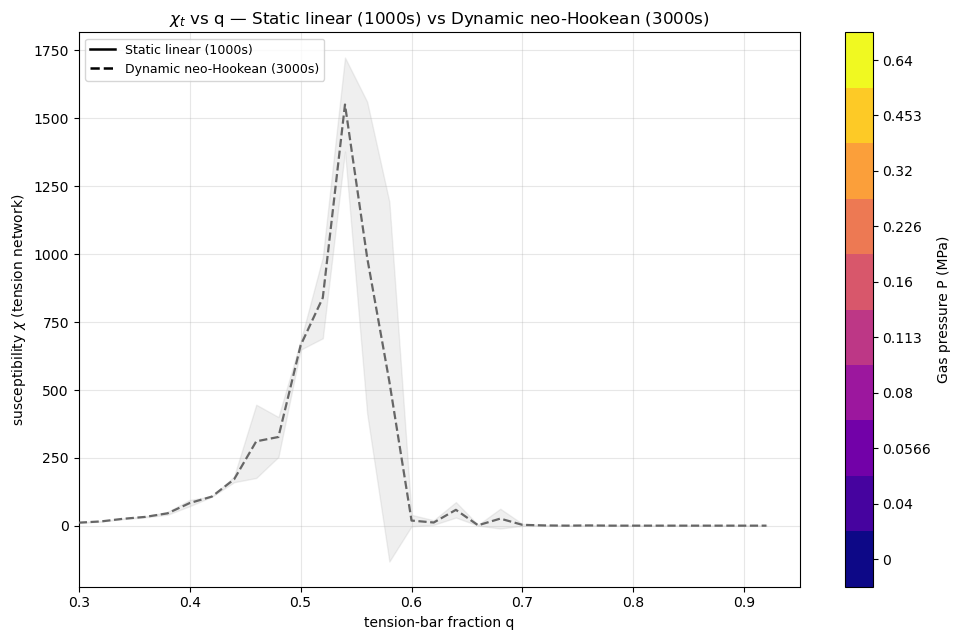

In [26]:
fig, ax = plt.subplots(figsize=(10, 6.5))

for fam in FAMILIES:
    for sim in fam['sims']:
        if sim not in CL:
            continue
        d = CL[sim]
        q = d['frac_tension']
        ax.plot(q, d['chi_t'], color=color_of(sim), linestyle=fam['ls'], linewidth=1.3, zorder=fam['zorder'])
        ip = int(np.argmax(d['chi_t']))
        ax.scatter(q[ip], d['chi_t'][ip], color=color_of(sim), marker=fam['marker'], s=45, zorder=6)

null_styles = {'1000s': ('k', '-'), '3000s': ('0.4', '--')}
for key, nu in NULL.items():
    c, ls = null_styles.get(key, ('k', '-'))
    ax.plot(nu['q'], nu['chi'], color=c, linestyle=ls, linewidth=1.6, zorder=7)
    ax.fill_between(nu['q'], nu['chi'] - nu['chi_sd'], nu['chi'] + nu['chi_sd'], color=c, alpha=0.10, zorder=0)

if not CL and not NULL:
    mark_unavailable(ax, 'Missing cluster-diagnostics and random-percolation caches for both families.')
ax.set_xlabel('tension-bar fraction q')
ax.set_ylabel(r'susceptibility $\chi$ (tension network)')
ax.set_title(r'$\chi_t$ vs q — Static linear (1000s) vs Dynamic neo-Hookean (3000s)')
ax.set_xlim(0.30, 0.95)
handles = family_legend_handles()
ax.legend(handles=handles, loc='upper left', fontsize=9)
add_colorbar(fig, ax)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
